# NB01 — Forecast Calibration & DC Price Diagnostic

Diagnoses two linked questions raised by the baseline benchmarking:

1. **Calibration:** Are the quantile forecasters well-calibrated? (Target: actual 80% interval coverage for q10–q90)
2. **DC Low price trend:** Is the DC Low revenue collapse in the OOS period a model failure or a market-conditions effect?

**Run order:** `train_forecasters.py` -> `data_quality.py` -> `run_baselines.py` -> this notebook.

---
### Critical data gap (read before interpreting DC results)

The DC auction results parquet (`data/raw/eso/dc_auction_results.parquet`) contains **zero rows for 2024 and 2025**.  
Data runs 2020–2023-11-02, then resumes 2026-03-31.  
As a result:
- All DC settlement prices in the 2025 OOS backtest were the 2023-11-02 closing price (£1.50/MW/h for DC Low), forward-filled by `resample('30min').ffill()` across 25 months.
- **OOS DC revenue figures in the backtest are based on stale 2023 prices — they are not reliable.**
- DC OOS calibration cannot be computed here (no actual 2025 DC prices exist as ground truth).
- DC OOF calibration covers only 2021-02-19 -> 2023-11-02.

## Section 0 — Imports and constants

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy import stats

# ---------------------------------------------------------------------------
# Paths — notebook lives in notebooks/, data one level up
# ---------------------------------------------------------------------------
DATA_DIR      = Path("../data")
RAW_DIR       = DATA_DIR / "raw"
FORECAST_DIR  = DATA_DIR / "forecasts"
OUTPUT_DIR    = DATA_DIR / "nb_outputs" / "nb01_calibration"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# OOS boundary for plot shading
OOS_START = pd.Timestamp("2025-01-01", tz="UTC")

# DC actual data gap boundaries
DC_ACTUAL_END   = pd.Timestamp("2023-11-02 23:00", tz="UTC")  # last real DC auction
DC_ACTUAL_GAP_END = pd.Timestamp("2026-03-31", tz="UTC")      # first 2026 auction

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

MARKET_LABELS = {"da": "DA", "bm": "BM", "dc_low": "DC Low", "dc_high": "DC High"}
COLOURS = {"da": "#2C7BB6", "bm": "#74ADD1", "dc_low": "#D7191C", "dc_high": "#FDAE61"}

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: /home/sakeenah/workspace/multimarket-bess-optimizer/data/nb_outputs/nb01_calibration


## Section 1 — Data loaders and coverage summary

Each market's actuals are loaded, parsed to a UTC DatetimeIndex, and inner-joined to the corresponding forecast parquets. A `period` column tags rows as `cv` (OOF 2021–2024) or `oos` (OOS 2025).

In [2]:
# ---------------------------------------------------------------------------
# DA — actual is hourly; forecast is 30-min.
# Forward-fill actual to 30-min so the join works; note that consecutive
# :00/:30 pairs share the same observed value (they are not independent).
# ---------------------------------------------------------------------------
da_raw = pd.read_parquet(RAW_DIR / "em_day_ahead" / "em_day_ahead_backfill.parquet")
da_raw["datetime"] = pd.to_datetime(da_raw["datetime"], utc=True)
da_actual_h = (
    da_raw
    .set_index("datetime")
    .sort_index()["value"]
)
da_actual_h = da_actual_h[~da_actual_h.index.duplicated(keep="first")]
da_actual_30 = da_actual_h.resample("30min").ffill()  # hourly -> 30-min

da_oof = pd.read_parquet(FORECAST_DIR / "da_oof_2021_2024.parquet")
da_oos = pd.read_parquet(FORECAST_DIR / "da_oos_2025.parquet")
da_oof["period"] = "cv"
da_oos["period"] = "oos"
da_fc = pd.concat([da_oof, da_oos]).sort_index()

da_aligned = da_fc.join(da_actual_30.rename("actual"), how="inner")
da_aligned = da_aligned.dropna(subset=["actual", "q10", "q50", "q90"])

print(f"DA aligned: {len(da_aligned):,} rows  "
      f"{da_aligned.index.min().date()} -> {da_aligned.index.max().date()}")
print(f"  CV rows: {(da_aligned['period']=='cv').sum():,}   "
      f"OOS rows: {(da_aligned['period']=='oos').sum():,}")

DA aligned: 86,023 rows  2021-01-29 -> 2025-12-31
  CV rows: 68,504   OOS rows: 17,519


In [3]:
# ---------------------------------------------------------------------------
# BM — actual is 30-min but systemSellPrice uses pandas nullable Float64.
# Must call .to_numpy(dtype=float, na_value=np.nan) before any numpy ops.
# ---------------------------------------------------------------------------
bm_frames = []
for f in sorted(RAW_DIR.glob("bmrs/*.parquet")):
    df = pd.read_parquet(f)
    df["startTime"] = pd.to_datetime(df["startTime"], utc=True)
    bm_frames.append(df.set_index("startTime")[["systemSellPrice"]])

bm_raw = pd.concat(bm_frames)
bm_raw = bm_raw[~bm_raw.index.duplicated(keep="last")].sort_index()

# Float64 -> plain float64 Series
bm_actual = pd.Series(
    bm_raw["systemSellPrice"].to_numpy(dtype=float, na_value=np.nan),
    index=bm_raw.index,
    name="actual",
)

bm_oof = pd.read_parquet(FORECAST_DIR / "bm_oof_2021_2024.parquet")
bm_oos = pd.read_parquet(FORECAST_DIR / "bm_oos_2025.parquet")
bm_oof["period"] = "cv"
bm_oos["period"] = "oos"
bm_fc = pd.concat([bm_oof, bm_oos]).sort_index()

bm_aligned = bm_fc.join(bm_actual, how="inner")
bm_aligned = bm_aligned.dropna(subset=["actual", "q10", "q50", "q90"])

print(f"BM aligned: {len(bm_aligned):,} rows  "
      f"{bm_aligned.index.min().date()} -> {bm_aligned.index.max().date()}")
print(f"  CV rows: {(bm_aligned['period']=='cv').sum():,}   "
      f"OOS rows: {(bm_aligned['period']=='oos').sum():,}")

BM aligned: 86,014 rows  2021-01-29 -> 2025-12-31
  CV rows: 68,494   OOS rows: 17,520


In [4]:
# ---------------------------------------------------------------------------
# DC Low and DC High
#
# CRITICAL: dc_auction_results.parquet has NO data for 2024 or 2025.
# After resample('30min').ffill(), the engine forward-filled the last
# 2023-11-02 value (£1.50/MW/h for DC Low) across all of 2024 and 2025.
#
# Consequence: the inner join between dc_aligned and any 2025 forecast rows
# WILL produce matches (the resampled series extends to 2026), but the
# 'actual' values in 2024-2025 are the stale 2023 price, not real prices.
# We explicitly restrict DC calibration to periods with real data (≤ DC_ACTUAL_END).
# ---------------------------------------------------------------------------
dc_raw = pd.read_parquet(RAW_DIR / "eso" / "dc_auction_results.parquet")

dcl_raw = (
    dc_raw[dc_raw["service"] == "DCL"]
    .set_index("delivery_start")["clearing_price"]
    .sort_index()
)
dch_raw = (
    dc_raw[dc_raw["service"] == "DCH"]
    .set_index("delivery_start")["clearing_price"]
    .sort_index()
)

dcl_30 = dcl_raw.resample("30min").ffill()
dch_30 = dch_raw.resample("30min").ffill()

# Load forecasts and tag period
dcl_oof = pd.read_parquet(FORECAST_DIR / "dc_low_oof_2021_2024.parquet")
dcl_oos = pd.read_parquet(FORECAST_DIR / "dc_low_oos_2025.parquet")
dcl_oof["period"] = "cv"
dcl_oos["period"] = "oos"
dcl_fc = pd.concat([dcl_oof, dcl_oos]).sort_index()

dch_oof = pd.read_parquet(FORECAST_DIR / "dc_high_oof_2021_2024.parquet")
dch_oos = pd.read_parquet(FORECAST_DIR / "dc_high_oos_2025.parquet")
dch_oof["period"] = "cv"
dch_oos["period"] = "oos"
dch_fc = pd.concat([dch_oof, dch_oos]).sort_index()

# Inner join then restrict to real DC actual data only
dcl_aligned_full = dcl_fc.join(dcl_30.rename("actual"), how="inner").dropna(
    subset=["actual", "q10", "q50", "q90"]
)
dcl_aligned = dcl_aligned_full[dcl_aligned_full.index <= DC_ACTUAL_END].copy()

dch_aligned_full = dch_fc.join(dch_30.rename("actual"), how="inner").dropna(
    subset=["actual", "q10", "q50", "q90"]
)
dch_aligned = dch_aligned_full[dch_aligned_full.index <= DC_ACTUAL_END].copy()

print(f"DC Low  aligned (real data only): {len(dcl_aligned):,} rows  "
      f"{dcl_aligned.index.min().date()} -> {dcl_aligned.index.max().date()}")
print(f"  CV rows: {(dcl_aligned['period']=='cv').sum():,}   "
      f"OOS rows: {(dcl_aligned['period']=='oos').sum():,}  "
      f"(OOS = 0 expected — no 2025 DC actual prices)")
print()
print(f"DC High aligned (real data only): {len(dch_aligned):,} rows  "
      f"{dch_aligned.index.min().date()} -> {dch_aligned.index.max().date()}")
print(f"  CV rows: {(dch_aligned['period']=='cv').sum():,}   "
      f"OOS rows: {(dch_aligned['period']=='oos').sum():,}")

DC Low  aligned (real data only): 38,974 rows  2021-02-19 -> 2023-11-02
  CV rows: 38,974   OOS rows: 0  (OOS = 0 expected — no 2025 DC actual prices)

DC High aligned (real data only): 36,918 rows  2021-09-24 -> 2023-11-02
  CV rows: 36,918   OOS rows: 0


In [5]:
# ---------------------------------------------------------------------------
# Coverage summary — one row per market per period
# ---------------------------------------------------------------------------
aligned = {
    "da":      da_aligned,
    "bm":      bm_aligned,
    "dc_low":  dcl_aligned,
    "dc_high": dch_aligned,
}

rows = []
for market, df in aligned.items():
    for period in ["cv", "oos"]:
        sub = df[df["period"] == period]
        if sub.empty:
            rows.append({"market": MARKET_LABELS[market], "period": period,
                         "rows": 0, "date_start": "—", "date_end": "—"})
            continue
        rows.append({
            "market": MARKET_LABELS[market],
            "period": period.upper(),
            "rows": len(sub),
            "date_start": str(sub.index.min().date()),
            "date_end":   str(sub.index.max().date()),
        })

coverage_summary = pd.DataFrame(rows)
print(coverage_summary.to_string(index=False))
print()
print("NOTE: DC OOS rows = 0 because no actual 2024/2025 DC auction prices exist in the raw data.")
print("NOTE: DC OOF ends 2023-11-02, not 2024-12-31 — final CV fold has no DC ground truth.")

 market period  rows date_start   date_end
     DA     CV 68504 2021-01-29 2024-12-26
     DA    OOS 17519 2025-01-01 2025-12-31
     BM     CV 68494 2021-01-29 2024-12-26
     BM    OOS 17520 2025-01-01 2025-12-31
 DC Low     CV 38974 2021-02-19 2023-11-02
 DC Low    oos     0          —          —
DC High     CV 36918 2021-09-24 2023-11-02
DC High    oos     0          —          —

NOTE: DC OOS rows = 0 because no actual 2024/2025 DC auction prices exist in the raw data.
NOTE: DC OOF ends 2023-11-02, not 2024-12-31 — final CV fold has no DC ground truth.


## Section 2 — Calibration diagnostics

**Target:** 80% of actuals should fall within the q10–q90 interval.  
**Under-coverage** (< 80%) -> intervals too narrow; the model is overconfident.  
**Over-coverage** (> 80%) -> intervals too wide; the model is underconfident.  

**Tail asymmetry:** Ideally ~10% below q10 and ~10% above q90. Asymmetry reveals directional bias in the tails.

**Note on DA:** DA actual is hourly; consecutive 30-min pairs (:00 and :30) share the same observed value after forward-filling. Row counts are approximately doubled vs true independent observations. Coverage fractions remain valid but confidence intervals on those fractions would be narrower than true uncertainty.

In [6]:
# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------

def calibration_table(df: pd.DataFrame) -> dict:
    """Return calibration metrics for a single aligned DataFrame."""
    y   = df["actual"].to_numpy(dtype=float)
    q10 = df["q10"].to_numpy(dtype=float)
    q50 = df["q50"].to_numpy(dtype=float)
    q90 = df["q90"].to_numpy(dtype=float)
    in_band  = (y >= q10) & (y <= q90)
    below_q10 = y < q10
    above_q90 = y > q90
    return {
        "n": len(y),
        "coverage_%": round(in_band.mean() * 100, 1),
        "below_q10_%": round(below_q10.mean() * 100, 1),
        "above_q90_%": round(above_q90.mean() * 100, 1),
        "asymmetry": round((below_q10.mean() - above_q90.mean()) * 100, 2),  # + = left-skewed tails
        "q50_bias": round((y - q50).mean(), 3),   # mean error of median forecast
        "q50_mae":  round(np.abs(y - q50).mean(), 3),
    }


def winkler_score(df: pd.DataFrame, alpha: float = 0.2) -> float:
    """80% prediction interval Winkler score (lower = better)."""
    y   = df["actual"].to_numpy(dtype=float)
    q10 = df["q10"].to_numpy(dtype=float)
    q90 = df["q90"].to_numpy(dtype=float)
    width = q90 - q10
    pen_lo = np.where(y < q10, (2 / alpha) * (q10 - y), 0.0)
    pen_hi = np.where(y > q90, (2 / alpha) * (y - q90), 0.0)
    return round(float((width + pen_lo + pen_hi).mean()), 3)


# ---------------------------------------------------------------------------
# Overall calibration table
# ---------------------------------------------------------------------------
rows = []
for market, df in aligned.items():
    for period in ["cv", "oos"]:
        sub = df[df["period"] == period]
        if sub.empty:
            rows.append({"market": MARKET_LABELS[market], "period": period.upper(),
                         "n": 0, "coverage_%": "—", "below_q10_%": "—",
                         "above_q90_%": "—", "asymmetry": "—",
                         "q50_bias": "—", "q50_mae": "—"})
            continue
        m = calibration_table(sub)
        m["market"] = MARKET_LABELS[market]
        m["period"] = period.upper()
        rows.append(m)

cal_df = pd.DataFrame(rows)[["market", "period", "n", "coverage_%",
                              "below_q10_%", "above_q90_%", "asymmetry",
                              "q50_bias", "q50_mae"]]
print("Calibration summary (target coverage = 80.0%)")
print(cal_df.to_string(index=False))
cal_df.to_csv(OUTPUT_DIR / "calibration_summary.csv", index=False)

Calibration summary (target coverage = 80.0%)
 market period     n coverage_% below_q10_% above_q90_% asymmetry q50_bias q50_mae
     DA     CV 68504       75.4        12.0        12.6     -0.58    4.192  21.568
     DA    OOS 17519       80.0        14.5         5.5      8.98   -4.317  15.055
     BM     CV 68494       76.4        10.7        12.9      -2.2    8.118   49.24
     BM    OOS 17520       85.5        10.1         4.3      5.84   -4.142  30.749
 DC Low     CV 38974       72.5        18.5         9.0      9.53    0.029   8.192
 DC Low    OOS     0          —           —           —         —        —       —
DC High     CV 36918       82.7         7.9         9.4     -1.54    1.033   2.129
DC High    OOS     0          —           —           —         —        —       —


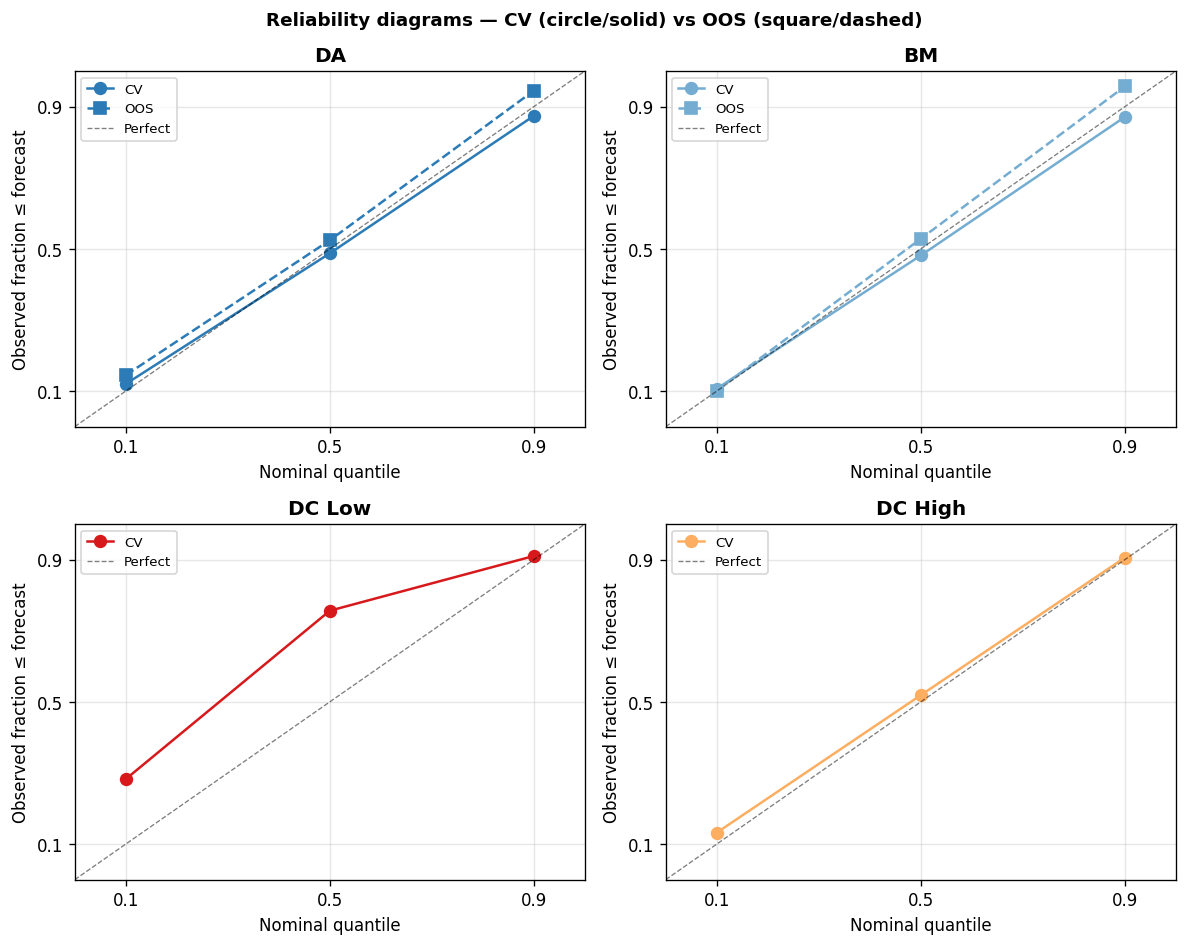

In [7]:
# ---------------------------------------------------------------------------
# Reliability diagrams — 2×2 grid, one panel per market
# For each quantile level q ∈ {0.10, 0.50, 0.90}, the observed fraction of
# actuals ≤ q-forecast should equal q (diagonal = perfect calibration).
# ---------------------------------------------------------------------------
QUANTILE_LEVELS = [0.10, 0.50, 0.90]
QUANTILE_COLS   = ["q10", "q50", "q90"]

markets_order = ["da", "bm", "dc_low", "dc_high"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, market in zip(axes, markets_order):
    df = aligned[market]
    colour = COLOURS[market]
    label  = MARKET_LABELS[market]

    for period, marker, ls in [("cv", "o", "-"), ("oos", "s", "--")]:
        sub = df[df["period"] == period]
        if sub.empty:
            continue
        y = sub["actual"].to_numpy(dtype=float)
        obs_fracs = [
            (y <= sub[col].to_numpy(dtype=float)).mean()
            for col in QUANTILE_COLS
        ]
        ax.plot(QUANTILE_LEVELS, obs_fracs,
                marker=marker, linestyle=ls, color=colour,
                label=period.upper(), linewidth=1.5, markersize=7)

    # Perfect calibration line
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.5, label="Perfect")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Nominal quantile")
    ax.set_ylabel("Observed fraction ≤ forecast")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([0.10, 0.50, 0.90])
    ax.set_yticks([0.10, 0.50, 0.90])

fig.suptitle("Reliability diagrams — CV (circle/solid) vs OOS (square/dashed)",
             fontweight="bold", fontsize=11)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "reliability_diagrams.png", bbox_inches="tight", dpi=120)
plt.show()

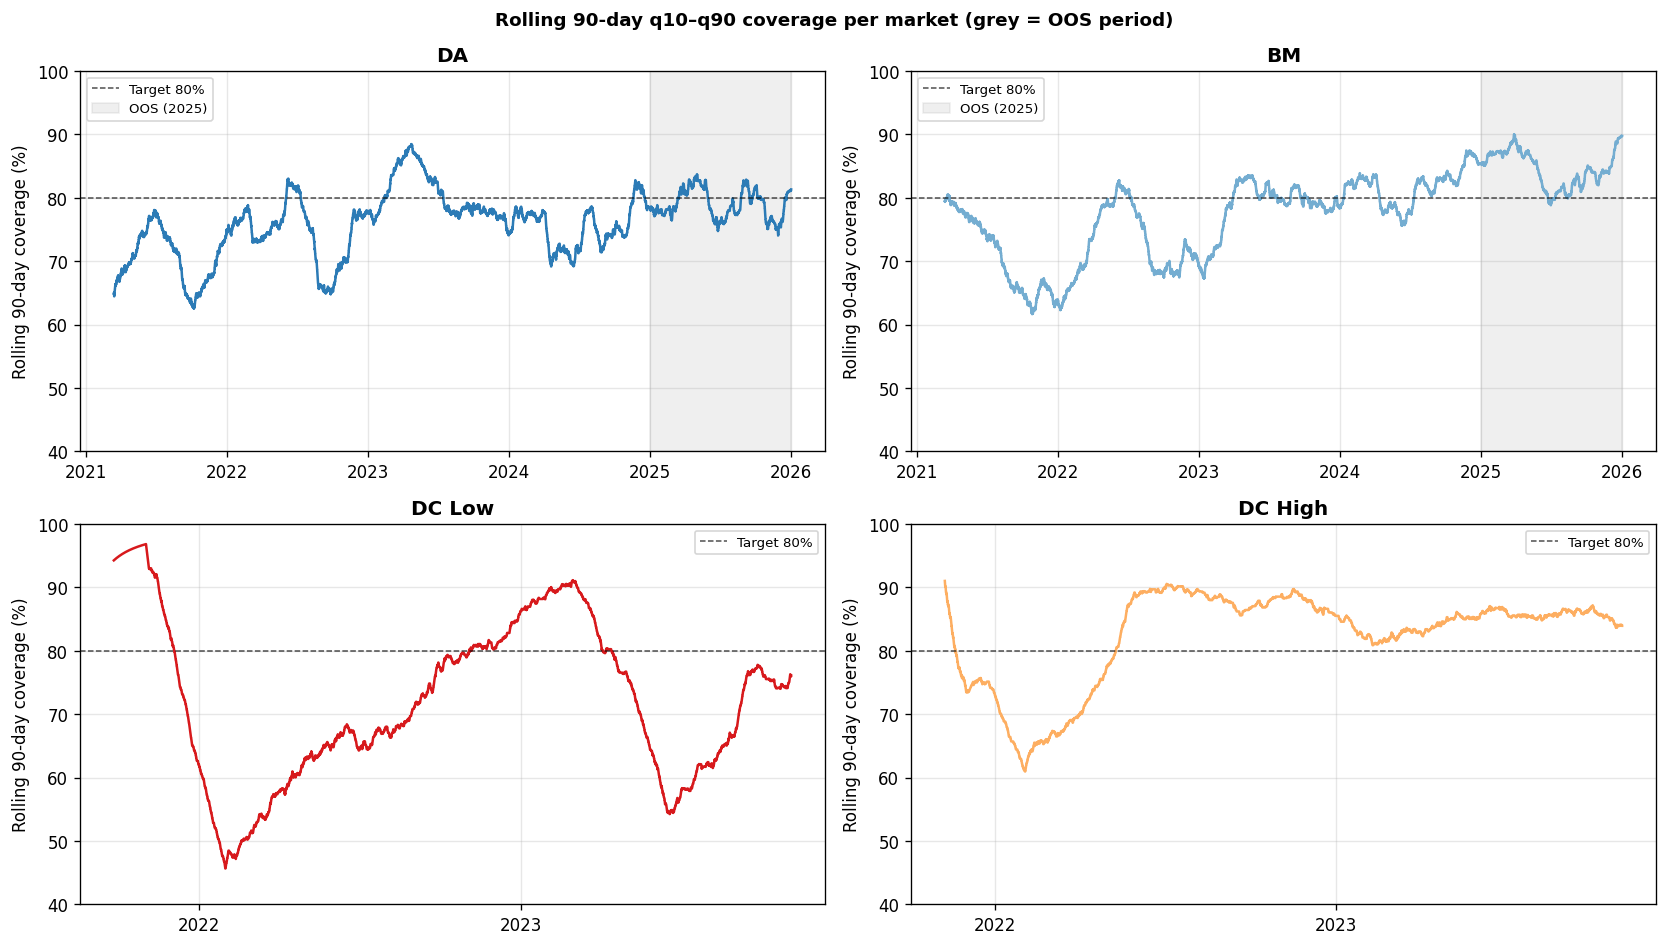

In [8]:
# ---------------------------------------------------------------------------
# Rolling 90-day coverage — 2×2 grid
# Shows whether calibration is stable over time or degrades in OOS.
# OOS region shaded grey. DC plots are OOF only (no OOS actuals).
# ---------------------------------------------------------------------------
WINDOW = 90 * 48  # 90 days × 48 half-hour periods

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
axes = axes.flatten()

for ax, market in zip(axes, markets_order):
    df = aligned[market]
    colour = COLOURS[market]
    label  = MARKET_LABELS[market]

    # Compute in-band flag
    in_band = (
        (df["actual"].to_numpy(dtype=float) >= df["q10"].to_numpy(dtype=float)) &
        (df["actual"].to_numpy(dtype=float) <= df["q90"].to_numpy(dtype=float))
    ).astype(float)
    s = pd.Series(in_band, index=df.index)

    roll = s.rolling(WINDOW, min_periods=WINDOW // 2).mean() * 100
    ax.plot(roll.index, roll.values, color=colour, linewidth=1.5)
    ax.axhline(80, color="black", linestyle="--", linewidth=0.9, alpha=0.7,
               label="Target 80%")

    # Shade OOS region
    xmin = df.index.min()
    xmax = df.index.max()
    if df.index.max() >= OOS_START:
        ax.axvspan(OOS_START, xmax, alpha=0.12, color="grey", label="OOS (2025)")

    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("Rolling 90-day coverage (%)")
    ax.set_ylim(40, 100)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Rolling 90-day q10–q90 coverage per market (grey = OOS period)",
             fontweight="bold", fontsize=11)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "rolling_coverage.png", bbox_inches="tight", dpi=120)
plt.show()

In [9]:
# ---------------------------------------------------------------------------
# CV vs OOS coverage split table + Winkler scores
# ---------------------------------------------------------------------------
rows = []
for market, df in aligned.items():
    for period in ["cv", "oos"]:
        sub = df[df["period"] == period]
        row = {"market": MARKET_LABELS[market], "period": period.upper()}
        if sub.empty:
            row.update({"n": 0, "coverage_%": "—", "winkler": "—",
                        "interval_width_mean": "—"})
        else:
            y   = sub["actual"].to_numpy(dtype=float)
            q10 = sub["q10"].to_numpy(dtype=float)
            q90 = sub["q90"].to_numpy(dtype=float)
            cov = ((y >= q10) & (y <= q90)).mean() * 100
            row.update({
                "n": len(sub),
                "coverage_%": round(cov, 1),
                "winkler": winkler_score(sub),
                "interval_width_mean": round((q90 - q10).mean(), 3),
            })
        rows.append(row)

split_df = pd.DataFrame(rows)
print("CV vs OOS — coverage and Winkler score (lower Winkler = better)")
print("Target coverage = 80.0%")
print(split_df.to_string(index=False))
split_df.to_csv(OUTPUT_DIR / "cv_oos_split.csv", index=False)

CV vs OOS — coverage and Winkler score (lower Winkler = better)
Target coverage = 80.0%
 market period     n coverage_%  winkler interval_width_mean
     DA     CV 68504       75.4  117.219              56.311
     DA    OOS 17519       80.0   84.611              40.659
     BM     CV 68494       76.4  220.599              126.79
     BM    OOS 17520       85.5  151.748             102.056
 DC Low     CV 38974       72.5   35.606              22.236
 DC Low    OOS     0          —        —                   —
DC High     CV 36918       82.7   10.507               8.206
DC High    OOS     0          —        —                   —


## Section 3 — DC Low price trend

Tests hypothesis H3: *DC Low revenue collapse in the OOS period is a market-conditions effect, not a model error.*

DC Low clearing prices are a market-level variable (set by ESO auction). If prices fell significantly after 2023, poor OOS revenue is structural. Since there are no 2024–2025 actual DC prices in this dataset, we rely on:
1. The trend within the available 2020–2023 actual data
2. What the DC Low forecaster's q50 predicts for 2025

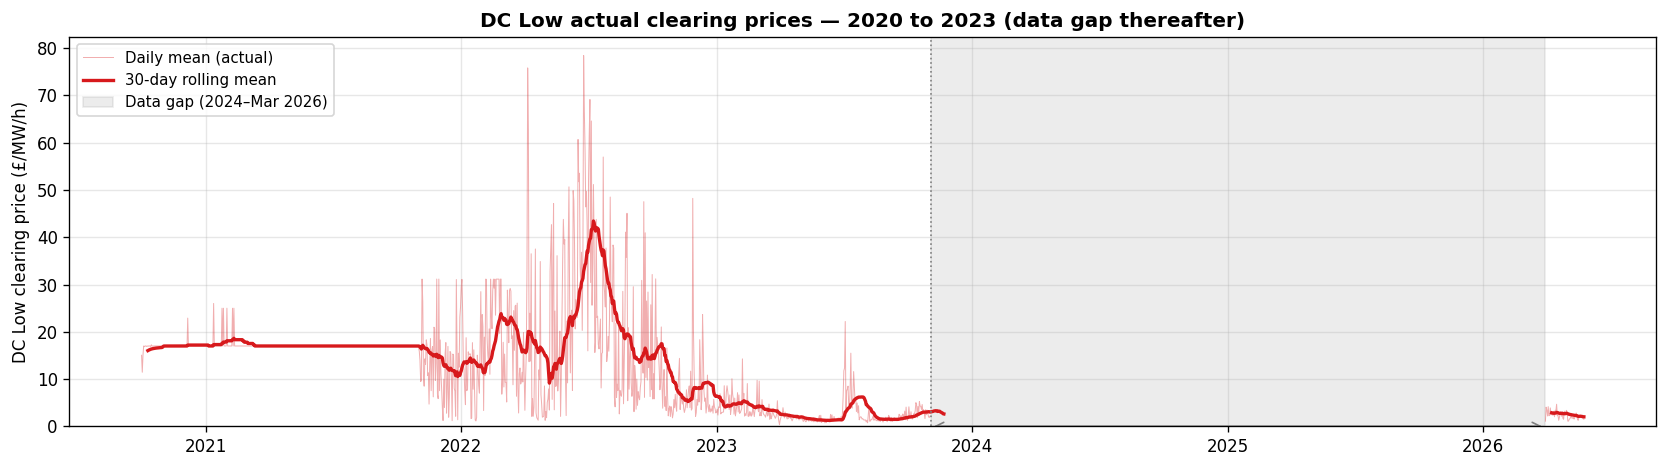

In [10]:
# ---------------------------------------------------------------------------
# DC Low actual price time series — available data only (2020–2023)
# With 30-day rolling mean and data-gap annotation.
# ---------------------------------------------------------------------------
dcl_daily = dcl_raw.resample("D").mean()  # daily mean from raw EFA-block prices

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(dcl_daily.index, dcl_daily.values,
        color="#D7191C", alpha=0.35, linewidth=0.6, label="Daily mean (actual)")
roll30 = dcl_daily.rolling(30, min_periods=10).mean()
ax.plot(roll30.index, roll30.values,
        color="#D7191C", linewidth=2.0, label="30-day rolling mean")

# Annotate the data gap
gap_patch = mpatches.FancyArrowPatch(
    posA=(DC_ACTUAL_END, 0), posB=(DC_ACTUAL_GAP_END, 0),
    arrowstyle="<->", color="grey", mutation_scale=12,
)
ax.add_patch(gap_patch)
ax.axvspan(DC_ACTUAL_END, DC_ACTUAL_GAP_END,
           alpha=0.15, color="grey", label="Data gap (2024–Mar 2026)")
ax.axvline(DC_ACTUAL_END, color="grey", linestyle=":", linewidth=1)

ax.set_ylabel("DC Low clearing price (£/MW/h)")
ax.set_title("DC Low actual clearing prices — 2020 to 2023 (data gap thereafter)",
             fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dc_low_price_trend.png", bbox_inches="tight", dpi=120)
plt.show()

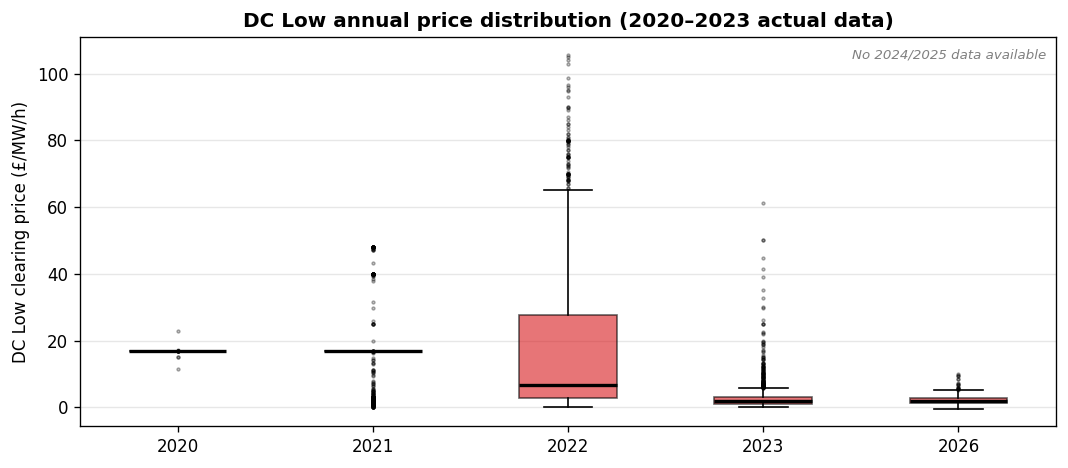

In [11]:
# ---------------------------------------------------------------------------
# Annual boxplot of DC Low clearing prices (actual data only, 2020–2023)
# ---------------------------------------------------------------------------
dcl_df = dcl_raw.to_frame("price")
dcl_df["year"] = dcl_df.index.year

years = sorted(dcl_df["year"].unique())
data_by_year = [dcl_df.loc[dcl_df["year"] == y, "price"].values for y in years]

fig, ax = plt.subplots(figsize=(9, 4))
bp = ax.boxplot(
    data_by_year,
    labels=[str(y) for y in years],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker=".", markersize=3, alpha=0.4),
)
for patch in bp["boxes"]:
    patch.set_facecolor("#D7191C")
    patch.set_alpha(0.6)

ax.set_ylabel("DC Low clearing price (£/MW/h)")
ax.set_title("DC Low annual price distribution (2020–2023 actual data)",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.text(0.99, 0.97, "No 2024/2025 data available",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=8, color="grey", fontstyle="italic")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dc_low_annual_boxplot.png", bbox_inches="tight", dpi=120)
plt.show()

In [12]:
# ---------------------------------------------------------------------------
# Annual summary statistics for DC Low clearing prices
# ---------------------------------------------------------------------------
stat_rows = []
for y in years:
    p = dcl_df.loc[dcl_df["year"] == y, "price"]
    stat_rows.append({
        "year": y,
        "n_auctions": len(p),
        "mean": round(p.mean(), 3),
        "median": round(p.median(), 3),
        "p10": round(p.quantile(0.10), 3),
        "p90": round(p.quantile(0.90), 3),
        "std": round(p.std(), 3),
        "max": round(p.max(), 3),
    })

stats_df = pd.DataFrame(stat_rows)
print("DC Low clearing price annual statistics (£/MW/h):")
print(stats_df.to_string(index=False))
print()
print("Trend: prices peaked in 2022 and fell sharply in 2023.")
print("2023 mean:", stats_df.loc[stats_df['year']==2023, 'mean'].values[0],
      "vs 2022 mean:", stats_df.loc[stats_df['year']==2022, 'mean'].values[0])
stats_df.to_csv(OUTPUT_DIR / "dc_low_annual_stats.csv", index=False)

DC Low clearing price annual statistics (£/MW/h):
 year  n_auctions   mean  median    p10    p90    std    max
 2020          92 16.959  17.000 16.990 17.000  0.898  22.90
 2021         900 15.467  17.000  1.199 17.000  9.839  47.99
 2022        2190 17.508   6.625  1.219 47.980 21.161 105.69
 2023        1835  2.896   1.950  0.790  5.250  4.076  61.36
 2026         330  2.358   1.980  0.970  4.397  1.615  10.00

Trend: prices peaked in 2022 and fell sharply in 2023.
2023 mean: 2.896 vs 2022 mean: 17.508


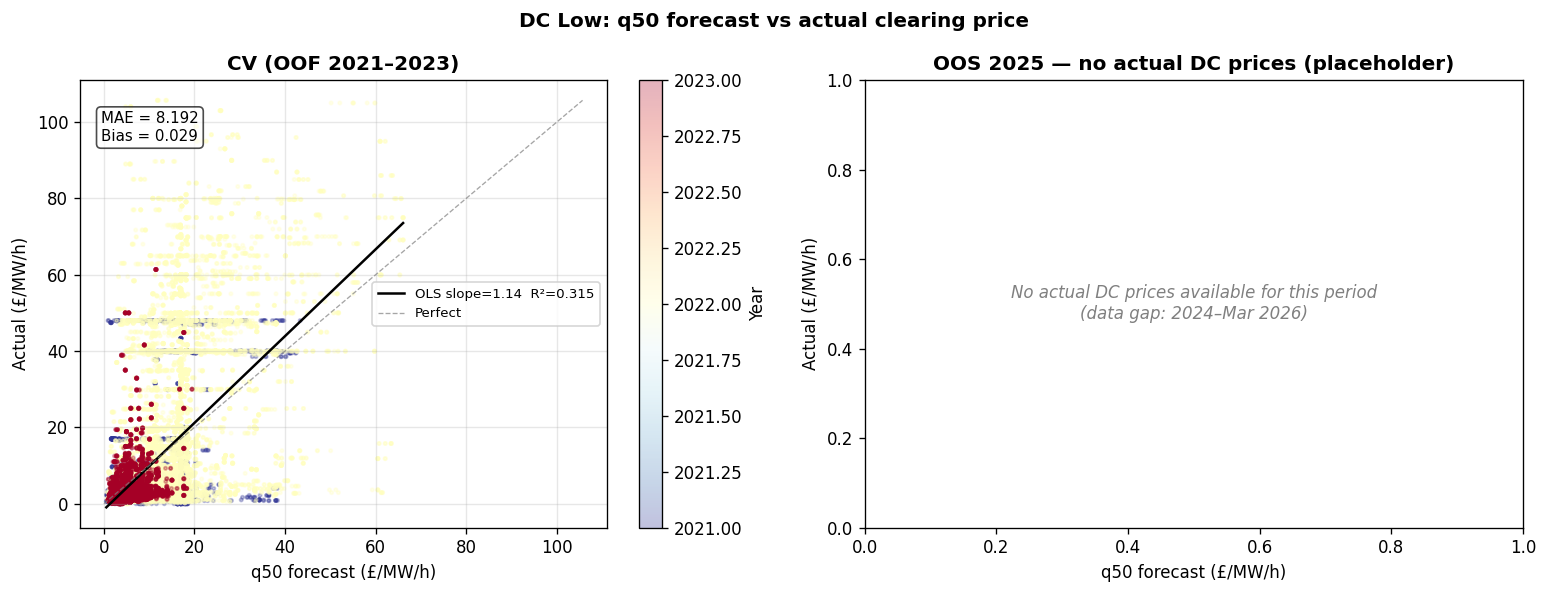

In [13]:
# ---------------------------------------------------------------------------
# DC Low q50 forecast vs actual scatter — OOF period only
# OLS regression line, MAE, and mean bias annotated.
# Colour by year to show drift over time.
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, period, title in [
    (axes[0], "cv",  "CV (OOF 2021–2023)"),
    (axes[1], "oos", "OOS 2025 — no actual DC prices (placeholder)"),
]:
    sub = dcl_aligned[dcl_aligned["period"] == period]

    if sub.empty:
        ax.text(0.5, 0.5, "No actual DC prices available for this period\n"
                "(data gap: 2024–Mar 2026)",
                ha="center", va="center", transform=ax.transAxes,
                fontsize=10, color="grey", fontstyle="italic")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("q50 forecast (£/MW/h)")
        ax.set_ylabel("Actual (£/MW/h)")
        continue

    y_hat = sub["q50"].to_numpy(dtype=float)
    y_act = sub["actual"].to_numpy(dtype=float)
    years_arr = sub.index.year

    scatter = ax.scatter(y_hat, y_act, c=years_arr, cmap="RdYlBu_r",
                         alpha=0.3, s=4, rasterized=True)
    fig.colorbar(scatter, ax=ax, label="Year")

    # OLS
    slope, intercept, r, p_val, _ = stats.linregress(y_hat, y_act)
    x_line = np.array([y_hat.min(), y_hat.max()])
    ax.plot(x_line, slope * x_line + intercept, "k-", linewidth=1.5,
            label=f"OLS slope={slope:.2f}  R²={r**2:.3f}")

    # Perfect forecast diagonal
    lims = [min(y_hat.min(), y_act.min()), max(y_hat.max(), y_act.max())]
    ax.plot(lims, lims, "--", color="grey", linewidth=0.8, alpha=0.7, label="Perfect")

    mae  = np.abs(y_act - y_hat).mean()
    bias = (y_act - y_hat).mean()
    ax.annotate(f"MAE = {mae:.3f}\nBias = {bias:.3f}",
                xy=(0.04, 0.93), xycoords="axes fraction",
                fontsize=9, va="top",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("q50 forecast (£/MW/h)")
    ax.set_ylabel("Actual (£/MW/h)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("DC Low: q50 forecast vs actual clearing price", fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dc_low_scatter.png", bbox_inches="tight", dpi=120)
plt.show()

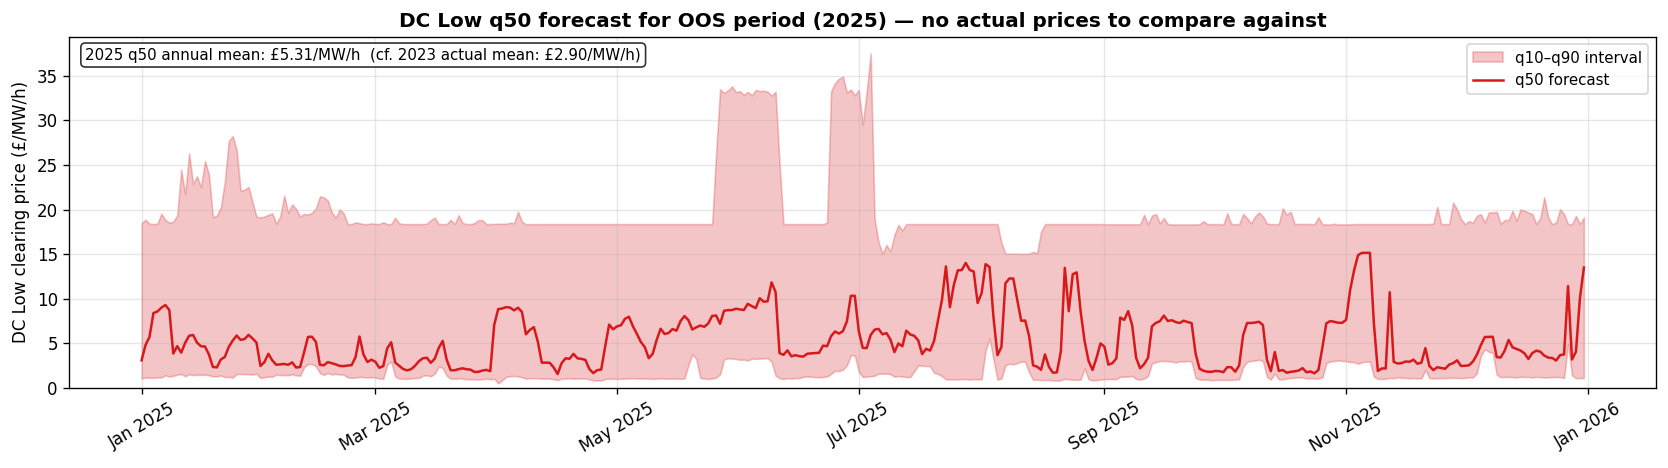

In [14]:
# ---------------------------------------------------------------------------
# DC Low q50 forecast for 2025 (OOS) — what does the model expect?
# Since there are no actual 2025 DC prices, we can only inspect the forecast.
# ---------------------------------------------------------------------------
dcl_oos_fc = pd.read_parquet(FORECAST_DIR / "dc_low_oos_2025.parquet")
dcl_daily_fc = dcl_oos_fc[["q10", "q50", "q90"]].resample("D").mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(dcl_daily_fc.index, dcl_daily_fc["q10"], dcl_daily_fc["q90"],
                alpha=0.25, color="#D7191C", label="q10–q90 interval")
ax.plot(dcl_daily_fc.index, dcl_daily_fc["q50"],
        color="#D7191C", linewidth=1.5, label="q50 forecast")

ax.set_ylabel("DC Low clearing price (£/MW/h)")
ax.set_title("DC Low q50 forecast for OOS period (2025) — no actual prices to compare against",
             fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
ax.text(0.01, 0.97,
        f"2025 q50 annual mean: £{dcl_daily_fc['q50'].mean():.2f}/MW/h  "
        f"(cf. 2023 actual mean: £{dcl_df.loc[dcl_df['year']==2023,'price'].mean():.2f}/MW/h)",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dc_low_oos_forecast.png", bbox_inches="tight", dpi=120)
plt.show()

## Section 4 — Hypothesis verdict

Fill in each verdict string after reviewing the plots above. Valid values: `"SUPPORTED"`, `"REFUTED"`, `"INCONCLUSIVE"`.

| ID | Hypothesis |
|---|---|
| H1 | Quantile coverage is **uniform over time** — the rolling-coverage plots show no systematic deterioration in the OOS period |
| H2 | Forecast **tails are symmetric** — the fraction of actuals below q10 ≈ fraction above q90 for all markets |
| H3 | DC Low OOS revenue collapse is a **market-conditions effect** (prices fell structurally post-2022), not a model forecasting error |

In [15]:
# ---------------------------------------------------------------------------
# Fill these in after reviewing the plots.
# ---------------------------------------------------------------------------
H1_VERDICT = ""  # e.g. "SUPPORTED", "REFUTED", "INCONCLUSIVE"
H1_NOTES   = ""  # e.g. "Coverage dips in OOS for BM but stable for DA"

H2_VERDICT = ""
H2_NOTES   = ""  # e.g. "BM has asymmetric upper tail — more large positive spikes than q90 captures"

H3_VERDICT = ""
H3_NOTES   = ""  # e.g. "DC Low mean fell from £X in 2022 to £Y in 2023; forecaster predicts £Z for 2025"

# Decision tree mapping verdict combos to recommended next actions
decision_tree = {
    ("SUPPORTED",   "SUPPORTED",   "SUPPORTED"):   "Calibration is good; market conditions explain OOS DC. Next: Experiment 02 (N_SCENARIOS sensitivity).",
    ("REFUTED",     "SUPPORTED",   "SUPPORTED"):   "Coverage degrades over time -> recalibrate with isotonic regression (Experiment 03).",
    ("SUPPORTED",   "REFUTED",     "SUPPORTED"):   "Tail asymmetry -> check for spike underprediction; consider asymmetric loss in training or separate spike model.",
    ("SUPPORTED",   "SUPPORTED",   "REFUTED"):     "DC Low model is causing revenue loss, not market conditions -> investigate DC feature engineering.",
    ("REFUTED",     "REFUTED",     "SUPPORTED"):   "Broad calibration failure -> recalibrate all markets before running further experiments.",
    ("INCONCLUSIVE","INCONCLUSIVE","INCONCLUSIVE"): "Insufficient data to conclude — consider collecting 2024/2025 DC actuals before proceeding.",
}

print("=" * 60)
print("HYPOTHESIS VERDICTS")
print("=" * 60)
for hid, verdict, notes in [
    ("H1", H1_VERDICT, H1_NOTES),
    ("H2", H2_VERDICT, H2_NOTES),
    ("H3", H3_VERDICT, H3_NOTES),
]:
    print(f"  {hid}: {verdict or '(not filled in)'}")
    if notes:
        print(f"       {notes}")
print()

key = (H1_VERDICT or "INCONCLUSIVE",
       H2_VERDICT or "INCONCLUSIVE",
       H3_VERDICT or "INCONCLUSIVE")
action = decision_tree.get(key, "Verdict combination not in tree — review manually.")
print("RECOMMENDED NEXT ACTION:")
print(" ", action)

HYPOTHESIS VERDICTS
  H1: (not filled in)
  H2: (not filled in)
  H3: (not filled in)

RECOMMENDED NEXT ACTION:
  Insufficient data to conclude — consider collecting 2024/2025 DC actuals before proceeding.


## Section 5 — Save aligned DataFrames and coverage summary

In [ ]:
# Save aligned DataFrames for use by downstream notebooks
for market, df in aligned.items():
    out_path = OUTPUT_DIR / f"{market}_aligned.parquet"
    df.to_parquet(out_path)
    print(f"Saved {out_path.name}  ({len(df):,} rows)")

# Save coverage summary
coverage_summary.to_parquet(OUTPUT_DIR / "coverage_summary.parquet")
print(f"Saved coverage_summary.parquet")
print()
print("All outputs in:", OUTPUT_DIR.resolve())
print("Contents:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")

In [14]:
trial_dc_df = pd.read_parquet('/home/sakeenah/workspace/multimarket-bess-optimizer/data/raw/eso/dc_auction_results.parquet')
trial_dc_df.columns

#print(trial_dc_df.serviceType.unique())
print(trial_dc_df.delivery_start)

0       2020-10-01 22:00:00+00:00
1       2020-10-02 22:00:00+00:00
2       2020-10-03 22:00:00+00:00
3       2020-10-04 22:00:00+00:00
4       2020-10-05 22:00:00+00:00
                   ...           
10340   2026-05-25 10:00:00+00:00
10341   2026-05-25 14:00:00+00:00
10342   2026-05-25 14:00:00+00:00
10343   2026-05-25 18:00:00+00:00
10344   2026-05-25 18:00:00+00:00
Name: delivery_start, Length: 10345, dtype: datetime64[us, UTC]
